In [1]:
!pip install sentence-transformers -q
!pip install seaborn -q

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# 10 sentences across 3 topics - cricket, cooking, cybersecurity
my_sentences = [
    # cricket
    "The opening batsman scored a century before lunch on day one.",
    "Both teams were equal on points so the match went to a super over.",
    "The fast bowler got the ball to swing late and clean bowled the batsman.",
    "India needed 14 runs off the last over to win the series.",

    # cooking
    "I added too much salt so I put a raw potato in to absorb it.",
    "The dough needs to rest for at least an hour before you roll it out.",
    "Roasting garlic in the oven makes it soft and much less sharp in taste.",

    # cybersecurity
    "Two factor authentication adds an extra layer of security to your account.",
    "The malware was hiding inside a legitimate looking PDF attachment.",
    "Always update your software because old versions have known security holes."
]

my_labels = [
    "Cric-1", "Cric-2", "Cric-3", "Cric-4",
    "Cook-1", "Cook-2", "Cook-3",
    "Cyber-1", "Cyber-2", "Cyber-3"
]

print("total sentences:", len(my_sentences))

total sentences: 10


In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(my_sentences)
print("embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embeddings shape: (10, 384)


In [5]:
sim_matrix = cosine_similarity(embeddings)
print(np.round(sim_matrix, 2))

[[ 1.    0.26  0.55  0.46  0.1   0.06  0.08  0.04  0.06 -0.  ]
 [ 0.26  1.    0.26  0.39  0.07 -0.03  0.06  0.06 -0.01 -0.07]
 [ 0.55  0.26  1.    0.39  0.08  0.13  0.08  0.03  0.08 -0.01]
 [ 0.46  0.39  0.39  1.    0.06  0.06  0.06  0.03  0.08  0.03]
 [ 0.1   0.07  0.08  0.06  1.    0.28  0.26  0.01  0.06  0.02]
 [ 0.06 -0.03  0.13  0.06  0.28  1.    0.17 -0.03  0.06  0.  ]
 [ 0.08  0.06  0.08  0.06  0.26  0.17  1.    0.02  0.06  0.07]
 [ 0.04  0.06  0.03  0.03  0.01 -0.03  0.02  1.    0.06  0.19]
 [ 0.06 -0.01  0.08  0.08  0.06  0.06  0.06  0.06  1.    0.34]
 [-0.   -0.07 -0.01  0.03  0.02  0.    0.07  0.19  0.34  1.  ]]


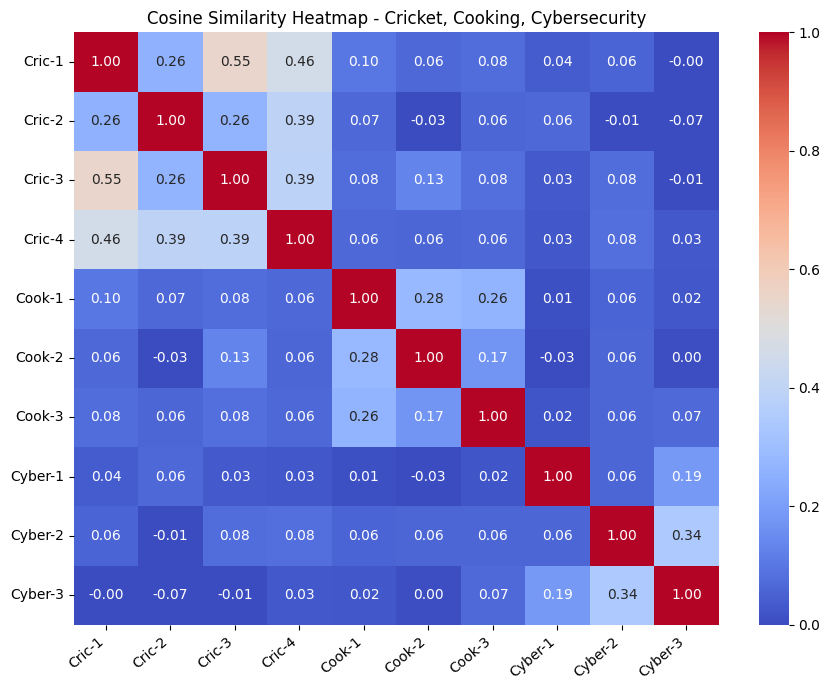

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=my_labels,
    yticklabels=my_labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)
plt.title("Cosine Similarity Heatmap - Cricket, Cooking, Cybersecurity")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig("heatmap_output.png", dpi=120)
plt.show()

In [7]:
query_sentence = "The bowler took three wickets in one over"
query_vec = model.encode([query_sentence])
scores = cosine_similarity(query_vec, embeddings)[0]
top2 = np.argsort(scores)[::-1][:2]

print("Query:", query_sentence)
print("\nTop 2 matches:\n")
for i, idx in enumerate(top2):
    print(f"Match {i+1}: {my_sentences[idx]}")
    print(f"Score: {scores[idx]:.4f}")
    print()

Query: The bowler took three wickets in one over

Top 2 matches:

Match 1: The fast bowler got the ball to swing late and clean bowled the batsman.
Score: 0.6811

Match 2: The opening batsman scored a century before lunch on day one.
Score: 0.4929

